We do the initial setup and loading. We need both the validation set (to find the optimal thresholds) and the test set (for the final unbiased evaluation).

In [1]:
import os
import time
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from transformers import AutoTokenizer

# Import modularized architectures
import sys
sys.path.append('..')
from models.lstm import BiLSTMClassifier
from models.transformers import UniversalTransformerClassifier

# Re-import dataset classes (ensure these match Notebook 2)
from src.data_utils import Vocabulary, LSTMDataset, BertDataset # Assuming you moved classes to a utils file, or paste them here

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models/saved_weights'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✅ Evaluating on device: {DEVICE}")

# Load all splits
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

# Identify labels
LABEL_COLS = [c for c in train_df.columns if c not in ['Argument ID', 'text_raw', 'text_clean']]

# Extract training arrays
X_train_raw = train_df['text_raw'].values
X_train_clean = train_df['text_clean'].values
y_train = train_df[LABEL_COLS].values

# Extract validation/test
X_val_raw = val_df['text_raw'].values
X_val_clean = val_df['text_clean'].values
y_val = val_df[LABEL_COLS].values

X_test_raw = test_df['text_raw'].values
X_test_clean = test_df['text_clean'].values
y_test = test_df[LABEL_COLS].values

print(f"✅ Data loaded: Train ({len(y_train)}), Val ({len(y_val)}), Test ({len(y_test)})")

✅ Evaluating on device: cuda
✅ Data loaded: Train (7112), Val (860), Test (893)


We create one function to get the raw logit predictions from a model and another to get the threshold that optimizes the F1-score

In [2]:
def get_predictions(model, loader, is_bert=False):
    """Runs inference and returns raw probabilities and inference time."""
    model.eval()
    all_probs = []
    
    start_time = time.time()
    with torch.no_grad():
        for batch in loader:
            if is_bert:
                input_ids = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                outputs = model(input_ids, mask)
            else:
                inputs = batch[0].to(DEVICE)
                outputs = model(inputs)
            
            # Convert logits to probabilities
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            
    inference_time = time.time() - start_time
    return np.array(all_probs), inference_time

def optimize_thresholds(y_true, y_probs):
    """Finds the best threshold (between 0.1 and 0.9) for each of the 20 classes."""
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_thresholds = []
    
    for class_idx in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in thresholds:
            preds = (y_probs[:, class_idx] > t).astype(int)
            f1 = f1_score(y_true[:, class_idx], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds.append(best_t)
        
    return np.array(best_thresholds)

We define the helper functions needed for training and class-imbalance weighting, so they are available for the ablation and learning curve experiments below.

In [3]:
import gc
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup

def calculate_pos_weights(y):
    """Calculates mathematically dampened positive weights to handle extreme class imbalance."""
    pos_counts = y.sum(axis=0)
    total_counts = y.shape[0]
    pos_counts = np.maximum(pos_counts, 1) # Prevent division by zero
    weights = np.sqrt((total_counts - pos_counts) / pos_counts)
    return torch.tensor(weights, dtype=torch.float32)

def train_engine(model, train_loader, val_loader, pos_weights, is_bert=False, epochs=10, lr=1e-3):
    """Unified training loop for both BiLSTM and Transformers."""
    model = model.to(DEVICE)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    
    if is_bert:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = None

    best_f1, best_state = 0, None
    
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            if is_bert:
                input_ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
                labels = batch['labels'].to(DEVICE)
                outputs = model(input_ids, mask)
            else:
                inputs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
                outputs = model(inputs)
                
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler: scheduler.step()
                
        # Quick validation using standard 0.5 threshold to track best epoch
        val_probs, _ = get_predictions(model, val_loader, is_bert=is_bert)
        val_f1 = f1_score(y_val, (val_probs > 0.5).astype(int), average='macro', zero_division=0)
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    if best_state: model.load_state_dict(best_state)
    return model, best_f1

print("✅ Helper functions defined.")

✅ Helper functions defined.


We instantiate the tokenizers and loaders needed for each architecture.

In [4]:
# 1. LSTM Setup
vocab = Vocabulary(pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))['text_clean'].values)
val_loader_lstm = DataLoader(LSTMDataset(val_df['text_clean'].values, y_val, vocab), batch_size=64)
test_loader_lstm = DataLoader(LSTMDataset(test_df['text_clean'].values, y_test, vocab), batch_size=64)

# 2. Transformer Loaders (we'll generate these dynamically in the execution cell to save memory)
def get_transformer_loaders(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    val_loader = DataLoader(BertDataset(val_df['text_raw'].values, y_val, tokenizer), batch_size=16)
    test_loader = DataLoader(BertDataset(test_df['text_raw'].values, y_test, tokenizer), batch_size=16)
    return val_loader, test_loader

We evaluate all trained models, optimize the threshold using the validation set, forecast the test set and display the results

Evaluate all models

In [5]:
import gc
import pandas as pd
import os
import torch
import numpy as np
from sklearn.metrics import f1_score

models_to_evaluate = [
    {'name': 'BiLSTM', 'is_bert': False, 'file': 'bilstm_best.pt', 'loader_name': None},
    {'name': 'DistilBERT', 'is_bert': True, 'file': 'distilbert_best.pt', 'loader_name': 'distilbert-base-uncased'},
    {'name': 'BERT (Base)', 'is_bert': True, 'file': 'bert_best.pt', 'loader_name': 'bert-base-uncased'},
    {'name': 'RoBERTa (Base)', 'is_bert': True, 'file': 'roberta_best.pt', 'loader_name': 'roberta-base'},
    # --- NEW HIGH-PARAMETER MODELS ---
    # {'name': 'BERT (Large)', 'is_bert': True, 'file': 'bert_large_best.pt', 'loader_name': 'bert-large-uncased'},
    # {'name': 'RoBERTa (Large)', 'is_bert': True, 'file': 'roberta_large_best.pt', 'loader_name': 'roberta-large'},
]

results = []

for m_info in models_to_evaluate:
    model_path = os.path.join(MODELS_DIR, m_info['file'])
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping {m_info['name']} (weights not found)")
        continue
        
    print(f"--- Evaluating {m_info['name']} ---")
    
    # Instantiate Model
    if m_info['is_bert']:
        model = UniversalTransformerClassifier(model_name=m_info['loader_name']).to(DEVICE)
        val_loader, test_loader = get_transformer_loaders(m_info['loader_name'])
    else:
        model = BiLSTMClassifier(vocab_size=len(vocab.vocab)).to(DEVICE)
        val_loader, test_loader = val_loader_lstm, test_loader_lstm
        
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # 1. Get Val Probs and Optimize Thresholds
    val_probs, _ = get_predictions(model, val_loader, is_bert=m_info['is_bert'])
    optimal_thresholds = optimize_thresholds(y_val, val_probs)
    
    # -> NEW: Print the discovered thresholds
    print(f"   Mean Optimal Threshold: {optimal_thresholds.mean():.2f}")
    print(f"   Thresholds array: {np.round(optimal_thresholds, 2)}")
    
    # 2. Get Test Probs and measure Inference Time
    test_probs, inf_time = get_predictions(model, test_loader, is_bert=m_info['is_bert'])
    
    # 3. Apply thresholds and calculate final F1
    test_preds = (test_probs > optimal_thresholds).astype(int)
    final_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    
    print(f"✅ {m_info['name']} Test F1-Macro: {final_f1:.4f} (Inference time: {inf_time:.2f}s)\n")
    
    results.append({
        'Model': m_info['name'],
        'F1-Macro': round(final_f1, 4),
        'Params': f"{params:,}",
        'Inference Time (s)': round(inf_time, 4),
        'ms/sample': round((inf_time / len(y_test)) * 1000, 3)
    })
    
    # Cleanup memory
    del model
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# Print final table to copy into LaTeX
# ==========================================
results_df = pd.DataFrame(results)
print("\n=== FINAL ARCHITECTURE COMPARISON ===")
print(results_df.to_string(index=False))

--- Evaluating BiLSTM ---
   Mean Optimal Threshold: 0.46
   Thresholds array: [0.35 0.25 0.5  0.25 0.5  0.3  0.45 0.45 0.35 0.35 0.5  0.5  0.55 0.7
 0.45 0.4  0.5  0.7  0.55 0.5 ]
✅ BiLSTM Test F1-Macro: 0.4913 (Inference time: 0.09s)

--- Evaluating DistilBERT ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Mean Optimal Threshold: 0.44
   Thresholds array: [0.45 0.35 0.55 0.65 0.4  0.25 0.4  0.35 0.4  0.4  0.45 0.6  0.6  0.55
 0.45 0.3  0.35 0.6  0.3  0.45]
✅ DistilBERT Test F1-Macro: 0.5349 (Inference time: 0.69s)



--- Evaluating BERT (Base) ---


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Mean Optimal Threshold: 0.51
   Thresholds array: [0.55 0.4  0.65 0.45 0.5  0.65 0.4  0.55 0.5  0.35 0.6  0.6  0.7  0.4
 0.5  0.35 0.45 0.6  0.5  0.4 ]
✅ BERT (Base) Test F1-Macro: 0.5293 (Inference time: 1.05s)

--- Evaluating RoBERTa (Base) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Mean Optimal Threshold: 0.49
   Thresholds array: [0.55 0.4  0.3  0.45 0.55 0.45 0.55 0.55 0.35 0.55 0.75 0.35 0.65 0.4
 0.4  0.3  0.55 0.7  0.45 0.6 ]
✅ RoBERTa (Base) Test F1-Macro: 0.5414 (Inference time: 0.99s)


=== FINAL ARCHITECTURE COMPARISON ===
         Model  F1-Macro      Params  Inference Time (s)  ms/sample
        BiLSTM    0.4913   3,440,788              0.0937      0.105
    DistilBERT    0.5349  66,378,260              0.6868      0.769
   BERT (Base)    0.5293 109,497,620              1.0479      1.174
RoBERTa (Base)    0.5414 124,661,012              0.9882      1.107


We compare the results we obtain against the baseline benchmark from assignment 1, creating visual plots as the raw table can be hard to read


=== FINAL ARCHITECTURE COMPARISON ===
            Model  F1-Macro      Params  Inference Time (s)  ms/sample
Baseline (LogReg)    0.5081     600,020              0.0539      0.034
           BiLSTM    0.4913   3,440,788              0.0937      0.105
       DistilBERT    0.5349  66,378,260              0.6868      0.769
      BERT (Base)    0.5293 109,497,620              1.0479      1.174
   RoBERTa (Base)    0.5414 124,661,012              0.9882      1.107

Saved table to ../results/architecture_comparison.csv


/tmp/ipykernel_80160/201708937.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1-Macro', palette=colors, ax=axes[0])
/tmp/ipykernel_80160/201708937.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Parameters_Num', palette=colors, ax=axes[1])
/tmp/ipykernel_80160/201708937.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='ms/sample', palette=colors, ax=axes[2])


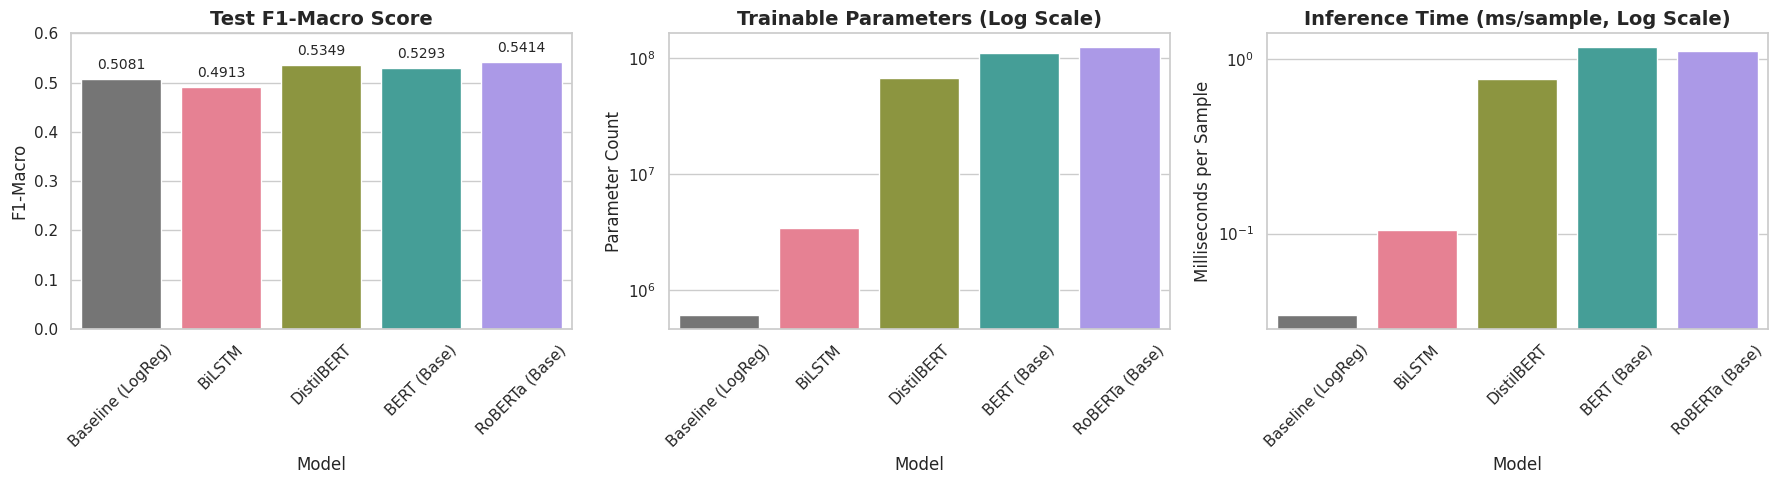

Saved visual comparisons to ../results/architecture_comparison_plots.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 1. Define Baseline Data (Matching the 'Params' key and string format)
baseline_data = {
    'Model': 'Baseline (LogReg)',
    'F1-Macro': 0.5081, 
    'Params': '600,020',  # Match the exact key and string format from the neural loop!
    'Inference Time (s)': 0.0539, 
    'ms/sample': 0.034
}

# 2. Build the DataFrame
results_df = pd.DataFrame([baseline_data] + results)

# -> NEW: Create a hidden numeric column strictly for Seaborn to plot mathematically
results_df['Parameters_Num'] = results_df['Params'].str.replace(',', '').astype(int)

print("\n=== FINAL ARCHITECTURE COMPARISON ===")
# Print cleanly without the hidden numeric column
print(results_df.drop(columns=['Parameters_Num']).to_string(index=False))

# Export for the LaTeX report
results_df.drop(columns=['Parameters_Num']).to_csv(os.path.join(RESULTS_DIR, 'architecture_comparison.csv'), index=False)
print(f"\nSaved table to {RESULTS_DIR}/architecture_comparison.csv")

# 3. Visual Comparisons
if len(results_df) > 1:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Use a distinct color palette
    colors = ['#757575'] + sns.color_palette("husl", len(results_df) - 1)

    # --- Plot A: F1-Macro ---
    sns.barplot(data=results_df, x='Model', y='F1-Macro', palette=colors, ax=axes[0])
    axes[0].set_title('Test F1-Macro Score', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('F1-Macro')
    axes[0].set_ylim(0, 0.6)
    
    # Add text labels on top of bars
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.4f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                         textcoords='offset points')

    # --- Plot B: Parameters (Log Scale) ---
    
    # Point Seaborn to the purely numeric column here!
    sns.barplot(data=results_df, x='Model', y='Parameters_Num', palette=colors, ax=axes[1])
    axes[1].set_title('Trainable Parameters (Log Scale)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Parameter Count')
    axes[1].set_yscale('log')

    # --- Plot C: Inference Time (Log Scale) ---
    sns.barplot(data=results_df, x='Model', y='ms/sample', palette=colors, ax=axes[2])
    axes[2].set_title('Inference Time (ms/sample, Log Scale)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Milliseconds per Sample')
    axes[2].set_yscale('log')

    # Formatting
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()

    # Save the plot for the LaTeX report
    plot_path = os.path.join(RESULTS_DIR, 'architecture_comparison_plots.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved visual comparisons to {plot_path}")
else:
    print("\n⚠️ Only baseline data available (no model weights found). Skipping plots.")

- BiLSTM model had the worst performance. This can be due to the lack of pretraining compared to the transformer models we used.
- All transformer models surpassed the statistical baseline (CountVec + LogReg)
- Transformer models did not necessarily benefit from increasing complexity and parameters. The lighter DistillBERT obtained a better performance than standard BERT. However, RoBERTa was the best performing models. Since the increase in complexity is not that much, we will keep it as our best model.

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# ==========================================
# LEARNING CURVE EXPERIMENT
# ==========================================
fractions = [0.25, 0.50, 0.75, 1.0]
lc_results = {'fraction': fractions, 'baseline': [], 'lstm': [], 'transformer': []}

for frac in fractions:
    print(f"\n{'='*40}")
    print(f"🚀 Running Experiment at {frac*100}% Training Data")
    print(f"{'='*40}")
    
    # --- Subsample training data ---
    if frac < 1.0:
        msss_sub = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=1.0-frac, random_state=42)
        train_idx, _ = next(msss_sub.split(X_train_raw, y_train))
        X_sub_raw, X_sub_clean, y_sub = X_train_raw[train_idx], X_train_clean[train_idx], y_train[train_idx]
    else:
        X_sub_raw, X_sub_clean, y_sub = X_train_raw, X_train_clean, y_train

    sub_weights = calculate_pos_weights(y_sub).to(DEVICE) 

    # ---------------------------------------------------------
    # A. Baseline (CountVec + LogReg) 
    # ---------------------------------------------------------
    print("--- Training Baseline ---")
    base_pipeline = Pipeline([
        ('vec', CountVectorizer(ngram_range=(1, 3), analyzer='char', lowercase=True, min_df=3, max_features=20000)),
        ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42)))
    ])
    base_pipeline.fit(X_sub_raw, y_sub)
    lc_results['baseline'].append(f1_score(y_test, base_pipeline.predict(X_test_raw), average='macro'))

    # ---------------------------------------------------------
    # B. BiLSTM
    # ---------------------------------------------------------
    print("--- Training BiLSTM ---")
    sub_vocab = Vocabulary(X_sub_clean, max_size=10000)
    
    sub_loader_lstm  = DataLoader(LSTMDataset(X_sub_clean, y_sub, sub_vocab), batch_size=64, shuffle=True)
    val_loader_lstm_lc  = DataLoader(LSTMDataset(X_val_clean, y_val, sub_vocab), batch_size=64)
    test_loader_lstm_lc = DataLoader(LSTMDataset(X_test_clean, y_test, sub_vocab), batch_size=64)
    
    model_lstm = BiLSTMClassifier(vocab_size=len(sub_vocab.vocab)).to(DEVICE)
    trained_lstm, _ = train_engine(
        model_lstm, sub_loader_lstm, val_loader_lstm_lc, 
        pos_weights=sub_weights, is_bert=False, epochs=15
    )
    
    probs_lstm, _ = get_predictions(trained_lstm, test_loader_lstm_lc, is_bert=False)
    lc_results['lstm'].append(f1_score(y_test, (probs_lstm > 0.5).astype(int), average='macro'))

    del model_lstm, trained_lstm
    gc.collect()
    torch.cuda.empty_cache()

    # ---------------------------------------------------------
    # C. Transformer (RoBERTa)
    # ---------------------------------------------------------
    print("--- Training RoBERTa ---")
    model_name_roberta = 'roberta-base'
    tokenizer_roberta = AutoTokenizer.from_pretrained(model_name_roberta)
    
    sub_loader_roberta  = DataLoader(BertDataset(X_sub_raw, y_sub, tokenizer_roberta), batch_size=16, shuffle=True)
    val_loader_roberta  = DataLoader(BertDataset(X_val_raw, y_val, tokenizer_roberta), batch_size=16)
    test_loader_roberta = DataLoader(BertDataset(X_test_raw, y_test, tokenizer_roberta), batch_size=16)
    
    roberta_model = UniversalTransformerClassifier(model_name=model_name_roberta).to(DEVICE)
    trained_roberta, _ = train_engine(
        roberta_model, sub_loader_roberta, val_loader_roberta, 
        pos_weights=sub_weights, is_bert=True, epochs=10, lr=2e-5
    )
    
    probs_tx, _ = get_predictions(trained_roberta, test_loader_roberta, is_bert=True)
    lc_results['transformer'].append(f1_score(y_test, (probs_tx > 0.5).astype(int), average='macro'))

    del roberta_model, trained_roberta
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# PLOTTING
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(fractions, lc_results['baseline'], label='Baseline (LogReg)', marker='o', linestyle='--')
plt.plot(fractions, lc_results['lstm'], label='BiLSTM', marker='s')
plt.plot(fractions, lc_results['transformer'], label='RoBERTa', marker='^')

plt.title('Experiment 2: Learning Curves (F1-Macro vs. Training Data %)', fontweight='bold')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Test F1-Macro')
plt.xticks(fractions, [f"{int(f*100)}%" for f in fractions])
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=300)
plt.show()


🚀 Running Experiment at 25.0% Training Data
--- Training Baseline ---
--- Training BiLSTM ---
--- Training RoBERTa ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
